In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
import optuna
import xgboost as xgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
warnings.filterwarnings("ignore")

In [53]:

df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')

print(df_train.shape) #何行何列か
print("") 
print(df_train.head()) #先頭5行を表示
print("") 
print(df_train.isnull().sum()) #全列の欠損値の数
print("") 
print(df_train['health_condition'].value_counts()) #health_condition 列に含まれる各カテゴリ（ユニークな値）の出現回数をカウントして、多い順に並べた

(690088, 15)

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy            5.22        70.6  25.66   
1   1          at-risk            5.53        71.3  25.84   
2   2        unhealthy            5.29        75.4  24.54   
3   3        unhealthy            4.70        77.2  23.13   
4   4          at-risk            7.23        73.4  28.44   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0               2174.0      1326.0               19.8          1.86       veg   
1               1966.0      9891.0               49.9          1.26   non-veg   
2               2688.0     14216.0               38.1          1.60       veg   
3               2630.0      7174.0               59.9          2.02       veg   
4               2560.0      6584.0               46.0          2.25       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  
0         high       average               sedentary 

In [54]:
print(df_test.head()) #先頭5行を表示
print("") 

       id  sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0  690088            5.35        64.9  23.48               2745.0     14167.0   
1  690089             NaN        83.1  22.42               1773.0      6801.0   
2  690090            6.68        59.7  24.14               3040.0     13250.0   
3  690091            7.13        78.5  26.26               2494.0      6331.0   
4  690092            5.49        77.7  23.29               1828.0     13894.0   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0               59.5          1.86       veg         high          poor   
1               24.5          2.40  balanced         high          poor   
2               48.5          2.76  balanced       medium          poor   
3               56.9          2.34       veg          low          good   
4               39.4          2.45       veg         high       average   

  physical_activity_level smoking_alcohol gender  
0          

'stress_level','sleep_quality','diet_type','smoking_alcohol','gender'
のデータの種類を見る

In [55]:
for col in ['stress_level','sleep_quality','diet_type','smoking_alcohol','gender']:
    print(f"\n{col}:")
    print(df_train[col].unique())


stress_level:
['high' 'low' nan 'medium']

sleep_quality:
['average' 'poor' nan 'good']

diet_type:
['veg' 'non-veg' 'balanced' nan]

smoking_alcohol:
['yes' 'occasional' nan 'no']

gender:
['female' 'other' 'male' nan]


In [56]:
# 順序ありカテゴリ
stress_map = {'low': 0, 'medium': 1, 'high': 2}
sleep_map = {'poor': 0, 'average': 1, 'good': 2}
activity_map = {'sedentary': 0, 'moderate': 1, 'active': 2}

for df in [df_train, df_test]: #df_train と df_test、両方に同じ処理をするループ 
    df['stress_level'] = df['stress_level'].map(stress_map) #stress_map1に沿って数字に手動変換
    df['sleep_quality'] = df['sleep_quality'].map(sleep_map) #stress_map2に沿って数字に手動変換
    df['physical_activity_level'] = df['physical_activity_level'].map(activity_map) #stress_map3に沿って数字に手動変換

stress_mode = df_train['stress_level'].mode()[0] #stress_levelの最頻値を取得
sleep_mode = df_train['sleep_quality'].mode()[0] #sleep_qualityの最頻値を取得
activity_mode = df_train['physical_activity_level'].mode()[0] #physical_activity_levelの最頻値を取得

#それぞれの欠損値をそれぞれの最頻値で埋める
df_train['stress_level'] = df_train['stress_level'].fillna(stress_mode)
df_test['stress_level'] = df_test['stress_level'].fillna(stress_mode)

df_train['sleep_quality'] = df_train['sleep_quality'].fillna(sleep_mode)
df_test['sleep_quality'] = df_test['sleep_quality'].fillna(sleep_mode)

df_train['physical_activity_level'] = df_train['physical_activity_level'].fillna(activity_mode)
df_test['physical_activity_level'] = df_test['physical_activity_level'].fillna(activity_mode)

# # 順序なしカテゴリ
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# for col in ['diet_type', 'smoking_alcohol', 'gender']:
#     #欠損値をunknownで埋める
#     df_train[col] = df_train[col].fillna('unknown')
#     df_test[col] = df_test[col].fillna('unknown')
#     #df_train と df_test を縦につなげて全部の値を把握
#     combined = pd.concat([df_train[col], df_test[col]])
#     #どんな値があるか覚えさせる
#     le.fit(combined)
#     #覚えた値を数値に変換する
#     df_train[col] = le.transform(df_train[col])
#     df_test[col] = le.transform(df_test[col])

# train/testを一旦結合して、カテゴリの種類を揃えてからOne-Hot化
categorical_cols = ['diet_type', 'smoking_alcohol', 'gender']

df_train = pd.get_dummies(df_train, columns=categorical_cols)
df_test = pd.get_dummies(df_test, columns=categorical_cols)

# train/testでカラムがズレないように揃える
df_train, df_test_ohe = df_train_ohe.align(df_test_ohe, join='left', axis=1, fill_value=0)

print(df_train.columns.tolist())

['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'stress_level', 'sleep_quality', 'physical_activity_level', 'diet_type_balanced', 'diet_type_non-veg', 'diet_type_veg', 'smoking_alcohol_no', 'smoking_alcohol_occasional', 'smoking_alcohol_yes', 'gender_female', 'gender_male', 'gender_other']


In [57]:
print(df_train.columns.tolist())

['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'stress_level', 'sleep_quality', 'physical_activity_level', 'diet_type_balanced', 'diet_type_non-veg', 'diet_type_veg', 'smoking_alcohol_no', 'smoking_alcohol_occasional', 'smoking_alcohol_yes', 'gender_female', 'gender_male', 'gender_other']


In [58]:
print(df_train['diet_type_balanced'].sum() + df_train['diet_type_non-veg'].sum() + df_train['diet_type_veg'].sum())
print(df_train.shape[0])

683187
690088


＝＝＝＝メモ＝＝＝＝

.map() は、辞書(dict)を使って列の値を1対1で置き換えるpandas

＜＜＜df['stress_level'] = df['stress_level'].map(stress_map)の処理内容＞＞＞

stress_map = {'low': 0, 'medium': 1, 'high': 2}

df['stress_level'] = df['stress_level'].map(stress_map)

元の列          →  変換後

'low'    →  stress_mapを見て → 0

'medium' →  stress_mapを見て → 1

'high'   →  stress_mapを見て → 2

＝＝＝＝メモ＝＝＝＝

欠損値が全部０になったかどうかの確認

In [59]:
# num_cols = ['sleep_duration', 'heart_rate', 'bmi',
#             'calorie_expenditure', 'step_count',
#             'exercise_duration', 'water_intake']

# for col in num_cols:
#     median_val = df_train[col].median()
#     df_train[col] = df_train[col].fillna(median_val)
#     df_test[col] = df_test[col].fillna(median_val)

# print(df_train.isnull().sum()) #全列の欠損値の数

In [60]:
print(df_train['physical_activity_level'].value_counts())

physical_activity_level
1.0    257662
0.0    219784
2.0    212642
Name: count, dtype: int64


In [61]:
features = ['sleep_duration', 'heart_rate', 'bmi',
            'calorie_expenditure', 'step_count',
            'exercise_duration', 'water_intake',
            'stress_level', 'sleep_quality',
            'physical_activity_level',
            'diet_type_balanced', 'diet_type_non-veg', 'diet_type_veg',
            'smoking_alcohol_no', 'smoking_alcohol_occasional', 'smoking_alcohol_yes',
            'gender_female', 'gender_male', 'gender_other']


X = df_train[features]
y = df_train['health_condition']

# ターゲットのラベルエンコード
from sklearn.preprocessing import LabelEncoder
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)
print(le_y.classes_)  # どの数字が何のクラスか確認

['at-risk' 'fit' 'unhealthy']


In [66]:
print(df_train['diet_type_balanced'].sum() + df_train['diet_type_non-veg'].sum() + df_train['diet_type_veg'].sum())
print(df_train.shape[0])

683187
690088


**特徴量同士の相関を見る**

In [63]:
# num_cols = ['sleep_duration', 'heart_rate', 'bmi',
#             'calorie_expenditure', 'step_count',
#             'exercise_duration', 'water_intake',
#             'diet_type', 'stress_level', 'sleep_quality',
#             'physical_activity_level', 'smoking_alcohol', 'gender']

# plt.figure(figsize=(10,8))
# sns.heatmap(df_train[num_cols].corr(),annot=True, cmap='coolwarm',fmt='.2f')
# plt.title('correlation of features')
# plt.show()

In [64]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, val_idx in skf.split(X, y_encoded):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_encoded[train_idx],y_encoded[val_idx]

    model = lgb.LGBMClassifier(random_state=42, verbose=-1,class_weight='balanced')
    model.fit(X_tr,y_tr)

    pred = model.predict(X_val)
    score = balanced_accuracy_score(y_val, pred)
    scores.append(score)
    print("scoreに追加した:", score)  # ← 確認用
    
print(scores)
print(f"平均: {np.mean(scores):.5f}")

scoreに追加した: 0.9097947770856164
scoreに追加した: 0.9095974174936279
scoreに追加した: 0.9099608929144513
scoreに追加した: 0.9094599212907394
scoreに追加した: 0.9084219896774514
[np.float64(0.9097947770856164), np.float64(0.9095974174936279), np.float64(0.9099608929144513), np.float64(0.9094599212907394), np.float64(0.9084219896774514)]
平均: 0.90945


**特徴量の重要度**

                       feature  importance
0               sleep_duration        1723
2                          bmi        1541
6                 water_intake         928
4                   step_count         816
1                   heart_rate         784
5            exercise_duration         750
3          calorie_expenditure         673
7                 stress_level         578
9      physical_activity_level         296
15         smoking_alcohol_yes         245
8                sleep_quality         198
13          smoking_alcohol_no         166
14  smoking_alcohol_occasional          81
17                 gender_male          58
11           diet_type_non-veg          45
10          diet_type_balanced          40
18                gender_other          35
12               diet_type_veg          30
16               gender_female          13


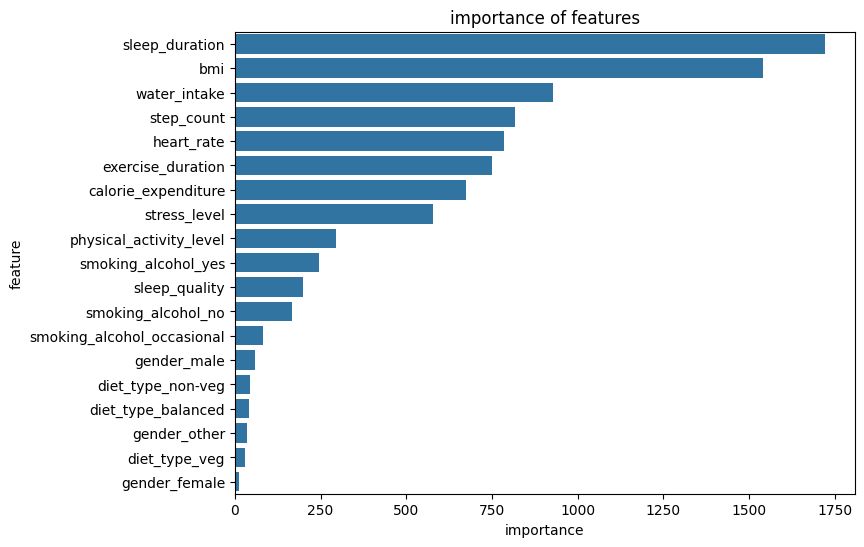

In [65]:
model = lgb.LGBMClassifier(random_state=42, verbose=-1,class_weight='balanced')
model.fit(X,y_encoded)

importance = pd.DataFrame({
    'feature': X.columns,
    'importance':model.feature_importances_
}).sort_values('importance',ascending=False)

print(importance)

plt.figure(figsize=(8,6))
sns.barplot(data=importance,x='importance',y='feature')
plt.title('importance of features')
plt.show()